# Image Rotations
[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/rbig/blob/main/docs/notebooks/12_image_rotations.ipynb)

RBIG provides specialized rotation transforms for image data. These operate
in the **spatial** or **channel** domain of images rather than treating pixels
as generic features.

All image rotations expect data in **flattened** format `(N, C·H·W)` and
reshape internally to `(N, C, H, W)` for computation.

| Class | Domain | Description |
|-------|--------|-------------|
| `DCTRotation` | Spatial (per-channel) | Type-II orthonormal 2-D Discrete Cosine Transform |
| `HartleyRotation` | Spatial (per-channel) | Real-valued 2-D Discrete Hartley Transform (self-inverse) |
| `RandomChannelRotation` | Channel (per-pixel) | Random orthogonal 1×1 convolution mixing channels |

All three are **orthonormal** → log\|det J\| = 0, so they add no cost to
density estimation.

For the general theory of rotation matrices in RBIG, see the [Rotation note](08_rotation_choices.ipynb).

> **Colab / fresh environment?** Run the cell below to install `rbig` from
> GitHub. Skip if already installed.

In [1]:
!pip install "rbig[all] @ git+https://github.com/jejjohnson/rbig.git" -q

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

from rbig import DCTRotation, HartleyRotation, RandomChannelRotation

/anaconda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## Grayscale Images (C=1)

We use the **sklearn digits dataset** — 1,797 handwritten digit images at
8×8 pixels. This is a real image dataset that's perfect for demonstrating
spatial transforms.

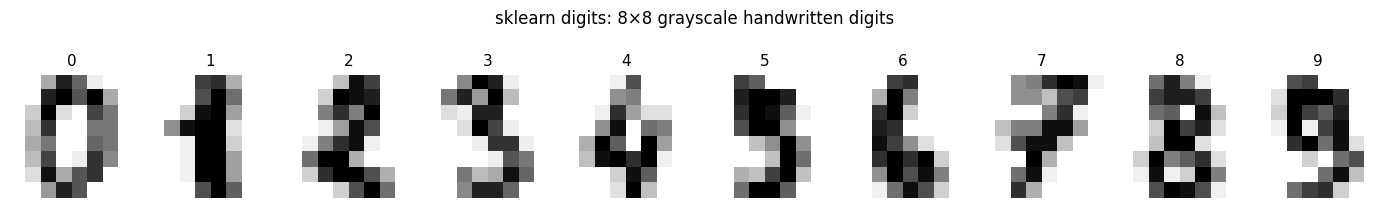

In [3]:
from sklearn.datasets import load_digits

rng = np.random.default_rng(42)

digits = load_digits()
images = digits.images  # (1797, 8, 8)
N, H, W = images.shape
C = 1
D = C * H * W  # 64

X_gray = images.reshape(N, D)  # flatten to (N, 64)

fig, axes = plt.subplots(1, 10, figsize=(14, 2))
for i, ax in enumerate(axes):
    ax.imshow(images[i], cmap="gray_r")
    ax.set_title(f"{digits.target[i]}", fontsize=11)
    ax.axis("off")
plt.suptitle("sklearn digits: 8×8 grayscale handwritten digits", y=1.05)
plt.tight_layout()
plt.show()

### DCTRotation

The **Discrete Cosine Transform** converts spatial pixel values to frequency
coefficients. It is widely used in image compression (JPEG) because natural
images have most energy in low-frequency components.

In RBIG, the DCT decorrelates spatial structure so the subsequent marginal
Gaussianization can work on approximately independent frequency bands.

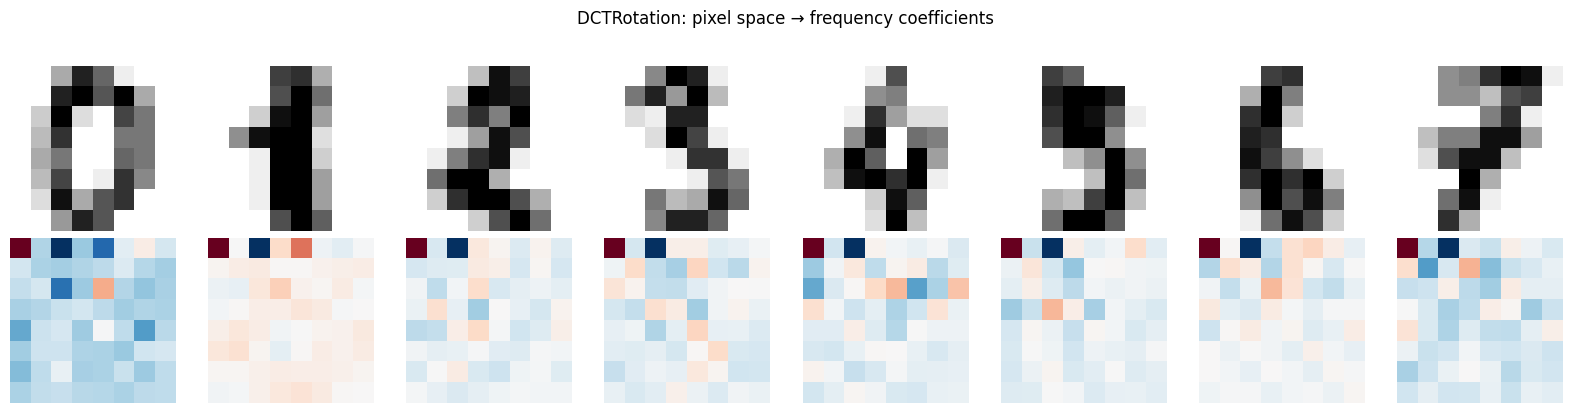

In [4]:
dct = DCTRotation(C=C, H=H, W=W)
dct.fit(X_gray)
X_dct = dct.transform(X_gray)

# Visualise: original vs DCT coefficients
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0, i].imshow(X_gray[i].reshape(H, W), cmap="gray_r")
    axes[0, i].axis("off")
    axes[1, i].imshow(X_dct[i].reshape(H, W), cmap="RdBu_r")
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("Pixels", fontsize=11)
axes[1, 0].set_ylabel("DCT", fontsize=11)
plt.suptitle("DCTRotation: pixel space → frequency coefficients", y=1.02)
plt.tight_layout()
plt.show()

DCT round-trip max error: 1.07e-14


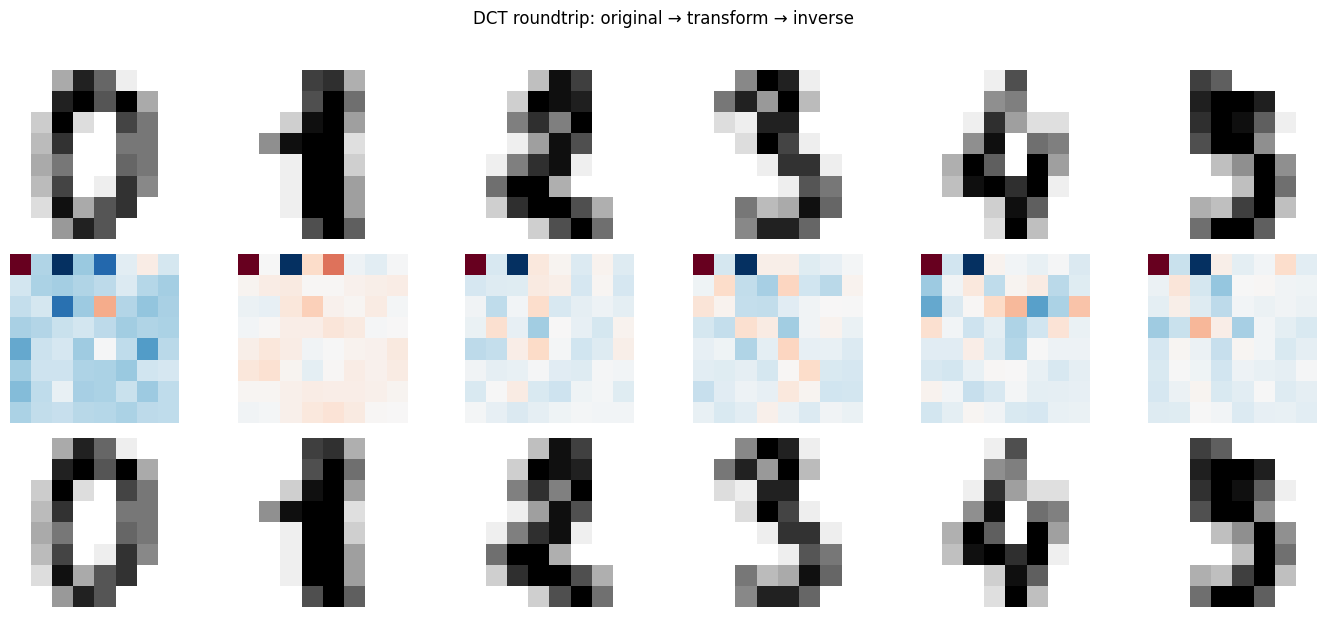

In [5]:
# Verify invertibility: original → DCT → inverse → reconstructed
X_rec_dct = dct.inverse_transform(X_dct)
print(f"DCT round-trip max error: {np.abs(X_gray - X_rec_dct).max():.2e}")

fig, axes = plt.subplots(3, 6, figsize=(14, 6))
for i in range(6):
    axes[0, i].imshow(X_gray[i].reshape(H, W), cmap="gray_r")
    axes[0, i].axis("off")
    axes[1, i].imshow(X_dct[i].reshape(H, W), cmap="RdBu_r")
    axes[1, i].axis("off")
    axes[2, i].imshow(X_rec_dct[i].reshape(H, W), cmap="gray_r")
    axes[2, i].axis("off")
axes[0, 0].set_ylabel("Original", fontsize=11)
axes[1, 0].set_ylabel("DCT coeffs", fontsize=11)
axes[2, 0].set_ylabel("Reconstructed", fontsize=11)
plt.suptitle("DCT roundtrip: original → transform → inverse", y=1.02)
plt.tight_layout()
plt.show()

### HartleyRotation

The **Discrete Hartley Transform** is similar to the DCT but uses a
different basis (cas = cos + sin). Its key property is that it is
**self-inverse**: applying it twice returns the original data.

In [6]:
hartley = HartleyRotation(C=C, H=H, W=W)
hartley.fit(X_gray)
X_hartley = hartley.transform(X_gray)

# Self-inverse property: transform twice = identity
X_rec_hartley = hartley.inverse_transform(X_hartley)
print(f"Hartley round-trip max error: {np.abs(X_gray - X_rec_hartley).max():.2e}")

Hartley round-trip max error: 7.11e-15


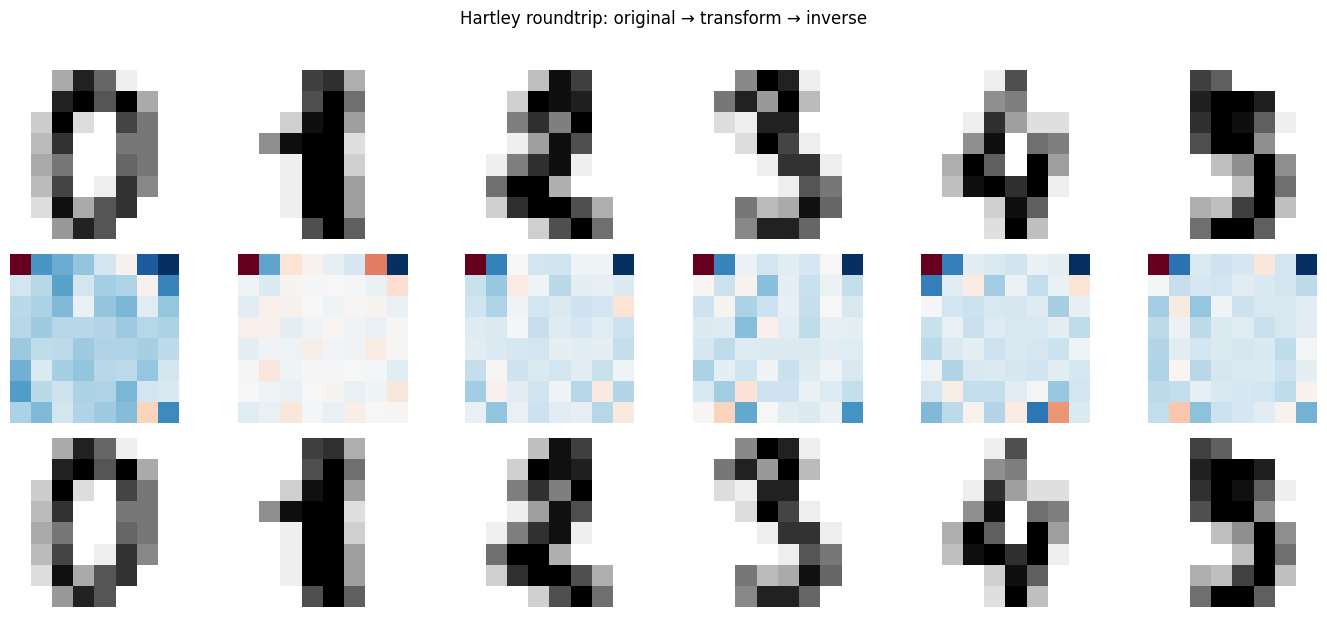

In [7]:
fig, axes = plt.subplots(3, 6, figsize=(14, 6))
for i in range(6):
    axes[0, i].imshow(X_gray[i].reshape(H, W), cmap="gray_r")
    axes[0, i].axis("off")
    axes[1, i].imshow(X_hartley[i].reshape(H, W), cmap="RdBu_r")
    axes[1, i].axis("off")
    axes[2, i].imshow(X_rec_hartley[i].reshape(H, W), cmap="gray_r")
    axes[2, i].axis("off")
axes[0, 0].set_ylabel("Original", fontsize=11)
axes[1, 0].set_ylabel("Hartley", fontsize=11)
axes[2, 0].set_ylabel("Reconstructed", fontsize=11)
plt.suptitle("Hartley roundtrip: original → transform → inverse", y=1.02)
plt.tight_layout()
plt.show()

### DCT vs Hartley: Coefficient Distribution

Both transforms decorrelate spatial structure. Let's compare how the
coefficient distributions look.

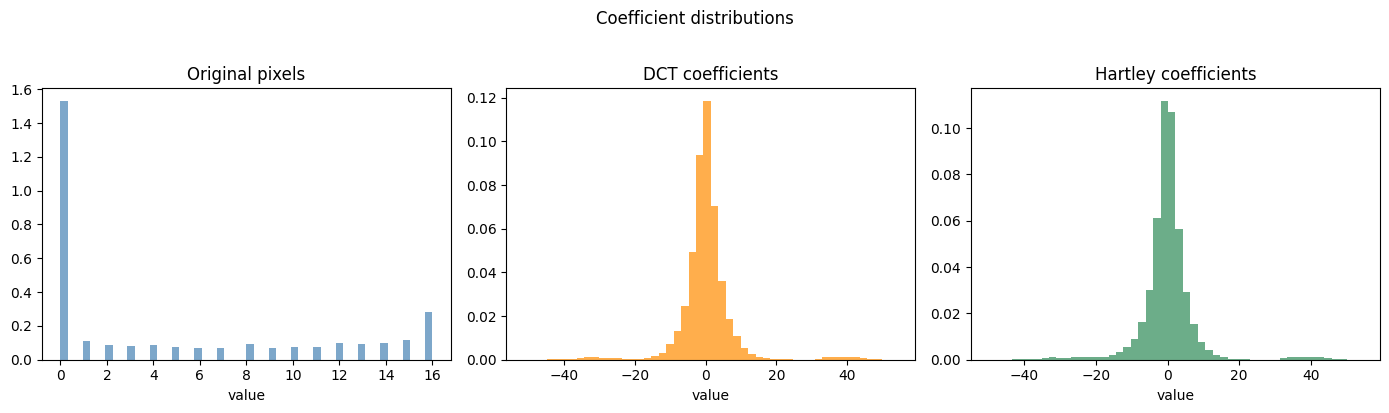

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(X_gray.ravel(), bins=50, alpha=0.7, color="steelblue", density=True)
axes[0].set_title("Original pixels")
axes[0].set_xlabel("value")

axes[1].hist(X_dct.ravel(), bins=50, alpha=0.7, color="darkorange", density=True)
axes[1].set_title("DCT coefficients")
axes[1].set_xlabel("value")

axes[2].hist(X_hartley.ravel(), bins=50, alpha=0.7, color="seagreen", density=True)
axes[2].set_title("Hartley coefficients")
axes[2].set_xlabel("value")

plt.suptitle("Coefficient distributions", y=1.02)
plt.tight_layout()
plt.show()

---
## Multi-Channel Images (C=3)

`RandomChannelRotation` is designed for **multi-channel** data. It applies
the same random orthogonal matrix at every spatial location — equivalent to
a 1×1 convolution that mixes channels.

This is useful when channels are correlated (e.g., R/G/B in natural images,
or multi-spectral bands in remote sensing).

We construct 3-channel images by stacking digit images from three
classes — these naturally have correlated spatial structure.

In [9]:
C_rgb = 3
# Use digits 0, 1, 2 as three "channels"
ch0 = digits.images[digits.target == 0][:200]
ch1 = digits.images[digits.target == 1][:200]
ch2 = digits.images[digits.target == 2][:200]
N_rgb = min(len(ch0), len(ch1), len(ch2))

images_rgb = np.stack([ch0[:N_rgb], ch1[:N_rgb], ch2[:N_rgb]], axis=1)  # (N, 3, 8, 8)
D_rgb = C_rgb * H * W

X_rgb = images_rgb.reshape(N_rgb, D_rgb)

### RandomChannelRotation

In [10]:
chan_rot = RandomChannelRotation(C=C_rgb, H=H, W=W, random_state=42)
chan_rot.fit(X_rgb)
X_chan = chan_rot.transform(X_rgb)

print(f"Rotation matrix shape: {chan_rot.rotation_matrix_.shape}")
print(f"Rotation matrix:\n{chan_rot.rotation_matrix_}")

Rotation matrix shape: (3, 3)
Rotation matrix:
[[-0.30565725  0.94407778 -0.12365595]
 [-0.94346673 -0.3177985  -0.09420534]
 [-0.12823484  0.08787073  0.98784339]]


RandomChannelRotation round-trip max error: 5.33e-15


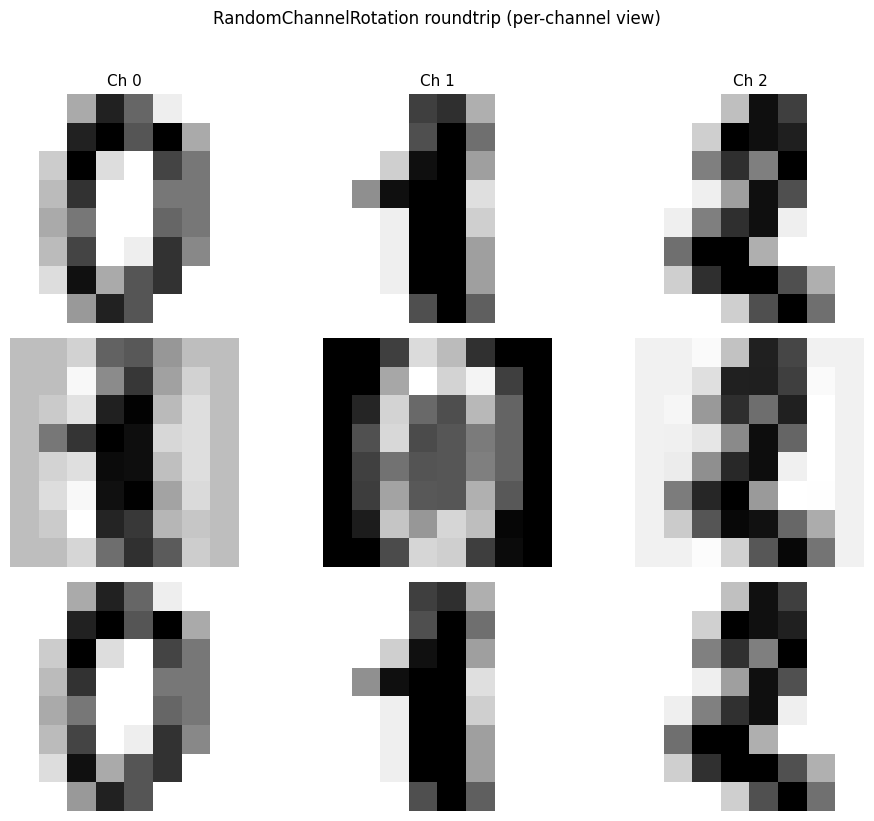

In [11]:
# Verify invertibility
X_rgb_rec = chan_rot.inverse_transform(X_chan)
print(f"RandomChannelRotation round-trip max error: {np.abs(X_rgb - X_rgb_rec).max():.2e}")

# Visualise: show each channel for one sample (original → rotated → reconstructed)
sample_idx = 0
fig, axes = plt.subplots(3, C_rgb, figsize=(10, 8))
titles_row = ["Original", "After channel rotation", "Reconstructed"]
data_rows = [
    images_rgb[sample_idx],
    X_chan[sample_idx].reshape(C_rgb, H, W),
    X_rgb_rec[sample_idx].reshape(C_rgb, H, W),
]
for row, (label, imgs_row) in enumerate(zip(titles_row, data_rows)):
    for c in range(C_rgb):
        axes[row, c].imshow(imgs_row[c], cmap="gray_r")
        axes[row, c].axis("off")
        if row == 0:
            axes[row, c].set_title(f"Ch {c}", fontsize=11)
    axes[row, 0].set_ylabel(label, fontsize=11)
plt.suptitle("RandomChannelRotation roundtrip (per-channel view)", y=1.02)
plt.tight_layout()
plt.show()

### Channel Correlation Before vs After

/tmp/ipykernel_3044710/2495139092.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


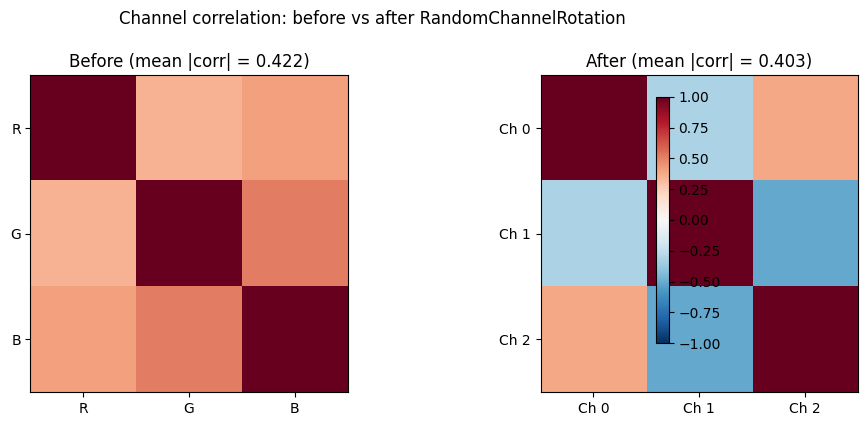

In [12]:
def channel_corr(flat, C, H, W):
    """Compute mean absolute cross-channel correlation."""
    imgs = flat.reshape(-1, C, H * W)  # (N, C, spatial)
    # Stack all spatial values per channel
    channels = [imgs[:, c].ravel() for c in range(C)]
    corr = np.corrcoef(channels)
    # Mean absolute off-diagonal
    mask = ~np.eye(C, dtype=bool)
    return np.abs(corr[mask]).mean(), corr


mean_corr_before, corr_before = channel_corr(X_rgb, C_rgb, H, W)
mean_corr_after, corr_after = channel_corr(X_chan, C_rgb, H, W)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im0 = axes[0].imshow(corr_before, cmap="RdBu_r", vmin=-1, vmax=1)
axes[0].set_title(f"Before (mean |corr| = {mean_corr_before:.3f})")
axes[0].set_xticks(range(C_rgb))
axes[0].set_yticks(range(C_rgb))
axes[0].set_xticklabels(["R", "G", "B"])
axes[0].set_yticklabels(["R", "G", "B"])

im1 = axes[1].imshow(corr_after, cmap="RdBu_r", vmin=-1, vmax=1)
axes[1].set_title(f"After (mean |corr| = {mean_corr_after:.3f})")
axes[1].set_xticks(range(C_rgb))
axes[1].set_yticks(range(C_rgb))
axes[1].set_xticklabels(["Ch 0", "Ch 1", "Ch 2"])
axes[1].set_yticklabels(["Ch 0", "Ch 1", "Ch 2"])

plt.colorbar(im1, ax=axes, shrink=0.8)
plt.suptitle("Channel correlation: before vs after RandomChannelRotation", y=1.02)
plt.tight_layout()
plt.show()

---
## Combining Spatial + Channel Rotations

In practice, you can compose a spatial transform (DCT or Hartley) with a
channel rotation for maximum decorrelation:

```python
# Example: DCT for spatial decorrelation + channel mixing
from rbig import RBIGLayer, MarginalGaussianize

spatial_rot = DCTRotation(C=3, H=8, W=8)
channel_rot = RandomChannelRotation(C=3, H=8, W=8, random_state=0)

# Apply DCT first, then channel rotation
Z = channel_rot.transform(spatial_rot.transform(X))
```

---
## Summary

| Class | Domain | Channels | Data-dependent? | Self-inverse? |
|-------|--------|----------|----------------|--------------|
| `DCTRotation` | Spatial | Per-channel (independent) | No | No (use `idctn`) |
| `HartleyRotation` | Spatial | Per-channel (independent) | No | Yes |
| `RandomChannelRotation` | Channel | Mixes channels | Yes (random Q) | No (use $Q^\top$) |

**Data format**: All expect `(N, C·H·W)` flattened input. Specify `C`, `H`,
`W` at construction time.

**When to use**:

- **DCT/Hartley** — when spatial correlation dominates (single-channel or
  independent channels). DCT is standard for image compression; Hartley is
  simpler (self-inverse).
- **RandomChannelRotation** — when channel correlation is significant
  (RGB, multispectral). Equivalent to a learned 1×1 conv in normalizing
  flow architectures (e.g., Glow).

---
## See Also

- [Rotation Note](08_rotation_choices.ipynb) — mathematical properties of rotation matrices in RBIG
- [Rotation Choices in RBIG](./08_rotation_choices.ipynb) — comparison of PCA, ICA, and random rotations
- [Dimensionality-Reducing Rotations](./13_dimensionality_reduction.ipynb) — rotations that reduce dimensionality